# Single-qubit X($\pi$): Gaussian vs. Gaussian+DRAG vs. Optimized

Six control waveforms for the same gate, evaluated three ways: the **predicted**
error budget $\sum_i w_i C_i$, the **true** three-level infidelity from a jax
simulation, and an **independent** QuTiP reading of the same waveform.

Then a $(\delta, \epsilon)$ noise sweep, and — the point of the exercise — the
optimizer's trajectory with the surrogate and the truth plotted on the same axes.

Specification: `README.md`. All heavy lifting is in `armlib.py`; this notebook
orchestrates and plots. Kernel: **Python (curve)**.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

sys.path.insert(0, str(Path.cwd()))
import armlib as al

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True, "figure.facecolor": "white"})

DEV = al.DEV
print(f"T           = {al.T:g} ns          M = {DEV.n_modes}")
print(f"Delta       = {DEV.delta:.6f} rad/ns   ({DEV.anharmonicity*1e3:+.0f} MHz)")
print(f"Omega_max   = {DEV.rabi_max_rate:.6f} rad/ns    eta = Omega_max/|Delta| = {DEV.eta:.3f}")
print(f"design eps  = {DEV.control_error:.1%}      design delta_z = {DEV.static_detuning*1e3:.1f} MHz rms")
print(f"decoh floor = {DEV.decoherence_floor:.4e}   (waveform independent, same for every arm)")
print(f"AWG export  = {al.N_EXPORT} samples @ {DEV.sample_rate} GS/s")
print(f"fluence unit F0 = pi^2/T = {al.FLUENCE_FLOOR:.5f} rad^2/ns")

T           = 50 ns          M = 20
Delta       = -1.256637 rad/ns   (-200 MHz)
Omega_max   = 0.314159 rad/ns    eta = Omega_max/|Delta| = 0.250
design eps  = 2.0%      design delta_z = 0.1 MHz rms
decoh floor = 4.1667e-04   (waveform independent, same for every arm)
AWG export  = 120 samples @ 2.4 GS/s
fluence unit F0 = pi^2/T = 0.19739 rad^2/ns


## 1. The arms

| Arm | Layer | Construction |
|---|---|---|
| **A** Gaussian | `planar` | truncated Gaussian $\sigma=T/6$, fitted to $M=20$ sine modes, `c1`-projected, $\Omega_y\equiv0$ |
| **B** Gaussian+DRAG | `planar_drag` | same $\kappa$, DRAG/Stark readout map supplies $\Omega_y$ — the industry baseline |
| **C** Optimized | `general` | `solve_budget`, warm started from B, free torsion $\tau$ |
| **D** Opt + fluence cap | `general` | same as C **plus hard cap** $\int\kappa^2dt \le 2F_0$ — the F06b "validity guard" (loaded from the recorded F06b cap-2$F_0$ run) |
| **E** Opt AD-exact | `general` | objective = **true-model expected infidelity** (nominal + ½⟨δ²⟩∂²_δ + ½⟨ε²⟩∂²_ε, all via AD through the three-level propagator); cap loosened to 4$F_0$ as a guard |
| **F** Opt AD-robust | `general` | F06f: objective = **sensitivity alone** (½⟨δ²⟩∂²_δ + ½⟨ε²⟩∂²_ε, zero-noise term dropped), zero-noise infidelity demoted to a hard fuse $e_0\le7.2\times10^{-6}$ (= B's level); evaluated on the **120-pt AWG grid**; no fluence cap, $\rho=0.8$; warm started from E. **Working point (non-claim)**: r1 last checkpoint, optimality 9.8e-9 |

Set `RESOLVE_ARM_C = True` to re-run arm C's ~9 minute solve instead of loading the
recorded F06-min run.

In [2]:
RESOLVE_ARM_C = False

arms = al.build_arms(resolve_c=RESOLVE_ARM_C)
for k in al.ARM_ORDER:
    a = arms[k]
    print(f"{k}  {a.name:16s} layer={a.layer:12s} ||a||={np.linalg.norm(a.a):.4f} "
          f"||c||={np.linalg.norm(a.c):.4e} Phi_0={a.Phi_0:+.4f}")
    print(f"     {a.note}")

A  Gaussian         layer=planar       ||a||=0.1163 ||c||=0.0000e+00 Phi_0=+0.0000
     Truncated Gaussian (sigma=T/6) fitted to M=20 sine modes, c1-projected and rescaled to theta=pi. Omega_y == 0: no DRAG, no Stark correction.
B  Gaussian + DRAG  layer=planar_drag  ||a||=0.1163 ||c||=0.0000e+00 Phi_0=+0.0000
     Truncated Gaussian (sigma=T/6), least-squares fit to M=20 sine modes (relRMS after c1 projection = 8.72e-03), DRAG/Stark readout. Task brief's headline 'industry baseline' -- first column of every result table.
C  Optimized (3D)   layer=general      ||a||=0.2860 ||c||=6.3858e-01 Phi_0=+0.4917
     solve_budget general-layer solution, warm started from Gaussian+DRAG, loaded from 20260808_F06min_gaussian3d_construction checkpoint iter=3100.
D  Opt + fluence cap layer=general      ||a||=0.1256 ||c||=2.0689e+00 Phi_0=-0.7807
     solve_budget general-layer solution with hard cap int kappa^2 dt <= 2*F0, warm started from Gaussian+DRAG, loaded from 20260810_F06b_fluence_cap2_mi200

## Fig. 1 — the control waveforms

Top row: the **played** waveform of each arm at the 120-point AWG sampling — what the
instrument would actually emit — with $\pm\Omega_{\max}$ as a dashed ceiling. Arm A's
$\Omega_y\equiv0$ is drawn so that B's DRAG quadrature is legible as a difference.

Bottom row: the **design curve** of all three arms — curvature $\kappa(t)$ (identical
for A and B by construction) and torsion $\tau(t)$, the degree of freedom only arm C
uses, against the R-guard bound $\rho|\Delta|/2$.

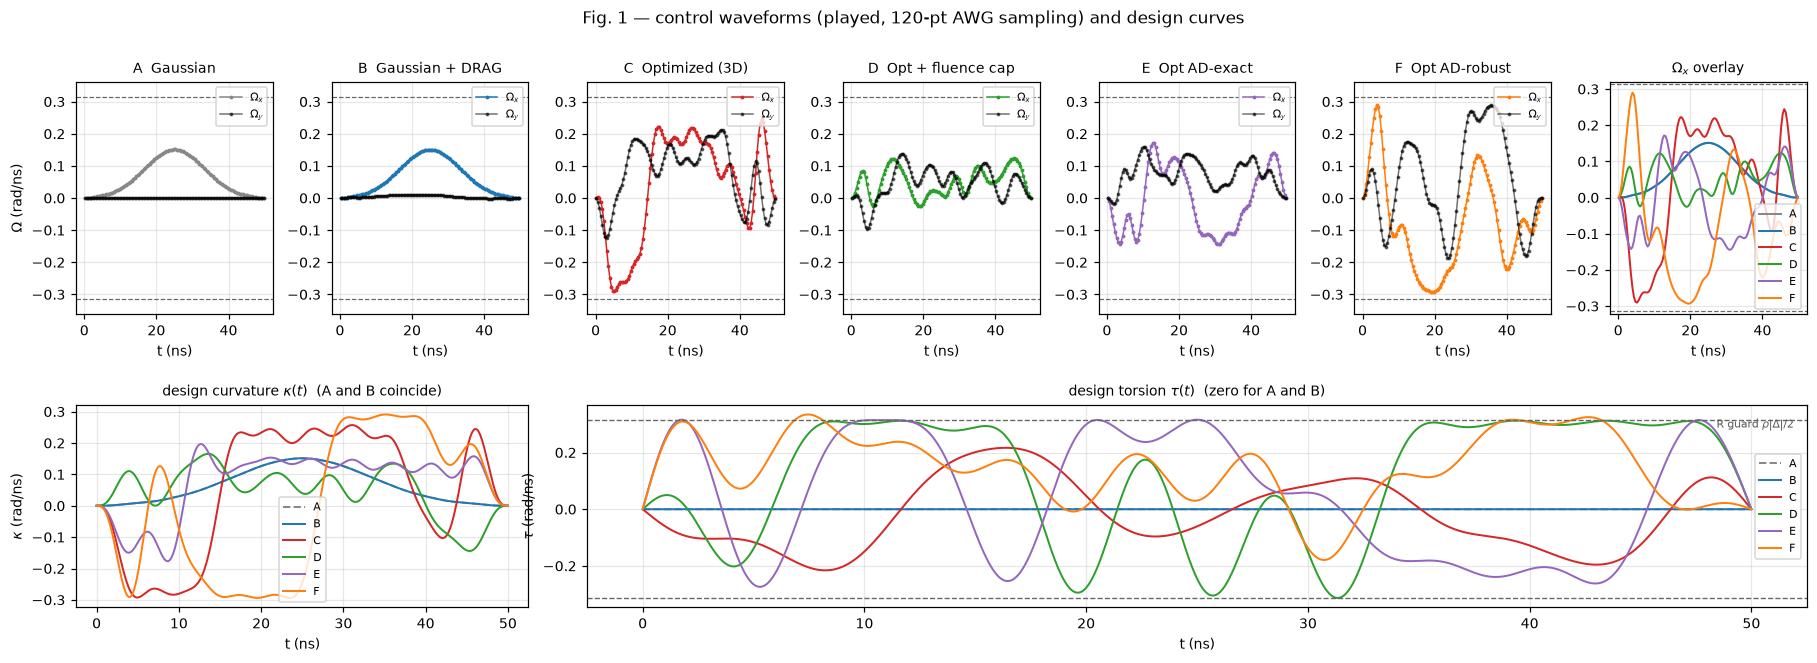

In [3]:
from curve_opt import geometry

t_awg, _ = geometry.midpoint_grid(al.T, al.N_EXPORT)
t_fine, _ = geometry.midpoint_grid(al.T, al.N_DESIGN)

n_arms = len(al.ARM_ORDER)
fig = plt.figure(figsize=(2.9 * (n_arms + 1), 6.2))
gs = fig.add_gridspec(2, n_arms + 1, height_ratios=[1.15, 1.0], hspace=0.42, wspace=0.30)

for i, k in enumerate(al.ARM_ORDER):
    ax = fig.add_subplot(gs[0, i])
    ox, oy = al.broadcast_of(arms[k], al.N_EXPORT)
    ax.plot(t_awg, ox, ".-", ms=3, lw=1.0, color=al.ARM_COLORS[k], label=r"$\Omega_x$")
    ax.plot(t_awg, oy, ".-", ms=3, lw=1.0, color="k", alpha=0.55, label=r"$\Omega_y$")
    for s in (+1, -1):
        ax.axhline(s * DEV.rabi_max_rate, ls="--", lw=0.8, color="0.4")
    ax.set_title(f"{k}  {arms[k].name}", fontsize=9)
    ax.set_xlabel("t (ns)")
    if i == 0:
        ax.set_ylabel(r"$\Omega$ (rad/ns)")
    ax.set_ylim(-1.15 * DEV.rabi_max_rate, 1.15 * DEV.rabi_max_rate)
    ax.legend(fontsize=7, loc="upper right")

ax = fig.add_subplot(gs[0, n_arms])
for k in al.ARM_ORDER:
    ox, _ = al.broadcast_of(arms[k], al.N_EXPORT)
    ax.plot(t_awg, ox, lw=1.3, color=al.ARM_COLORS[k], label=k)
for s in (+1, -1):
    ax.axhline(s * DEV.rabi_max_rate, ls="--", lw=0.8, color="0.4")
ax.set_title(r"$\Omega_x$ overlay", fontsize=9)
ax.set_xlabel("t (ns)")
ax.legend(fontsize=7)

axk = fig.add_subplot(gs[1, :2])
axt = fig.add_subplot(gs[1, 2:])
for k in al.ARM_ORDER:
    dc = al.design_of(arms[k], al.N_DESIGN)
    ls = "--" if k == "A" else "-"
    axk.plot(t_fine, np.asarray(dc.kappa), ls, lw=1.3, color=al.ARM_COLORS[k], label=k)
    axt.plot(t_fine, np.asarray(dc.tau), ls, lw=1.3, color=al.ARM_COLORS[k], label=k)
axk.set_xlabel("t (ns)"); axk.set_ylabel(r"$\kappa$ (rad/ns)")
axk.set_title(r"design curvature $\kappa(t)$  (A and B coincide)", fontsize=9)
axk.legend(fontsize=7)
guard = 0.5 * abs(DEV.delta) / 2.0
for s in (+1, -1):
    axt.axhline(s * guard, ls="--", lw=0.9, color="0.4")
axt.text(0.99, 0.93, r"R guard $\rho|\Delta|/2$", transform=axt.transAxes,
         ha="right", va="top", fontsize=7, color="0.35")
axt.set_xlabel("t (ns)"); axt.set_ylabel(r"$\tau$ (rad/ns)")
axt.set_title(r"design torsion $\tau(t)$  (zero for A and B)", fontsize=9)
axt.legend(fontsize=7)

fig.suptitle("Fig. 1 — control waveforms (played, 120-pt AWG sampling) and design curves", y=0.985)
plt.show()

## 2. Table 1 — the noiseless comparison

$C_1,C_2,C_3$ are evaluated on the **design curve**; the gate residual, $C_4$ and the
peak on the **played** waveform (project red line). Arm A's $C_4$ is computed directly
on its played waveform rather than through `budget.budget_terms`, which would apply the
DRAG readout map to an undragged pulse.

$\Phi_{\rm vz}$ is calibrated once per arm here, at $\delta=\epsilon=0$, and **frozen**
for the whole sweep below.

> ⚠️ **Reading $C_1$–$C_4$ for arms D/E/F**: since F06e the costs are **report
> quantities, not objectives** — E minimizes the AD-exact expected infidelity, F the
> AD-exact sensitivities. The $C_1$–$C_4$ formulas are low-order design-curve
> surrogates whose $\tau\neq0$ readout map is truncated at $O(\eta)$ (F06d), so at
> $\max|\tau|\gtrsim0.1$ and high fluence they **misreport the physics** (F sits
> deepest in that region). Large $C_i$ there does *not* mean large error — the
> arbiter is the `true` columns (jax + QuTiP, independent numerics).

In [4]:
rows = {k: al.characterize(arms[k]) for k in al.ARM_ORDER}
qchk = {k: al.qutip_cross_check(arms[k]) for k in al.ARM_ORDER}

tab = pd.DataFrame({
    "arm": [f"{k} {arms[k].name}" for k in al.ARM_ORDER],
    "C1": [rows[k]["c1"] for k in al.ARM_ORDER],
    "C2": [rows[k]["c2"] for k in al.ARM_ORDER],
    "C3": [rows[k]["c3"] for k in al.ARM_ORDER],
    "C4": [rows[k]["c4"] for k in al.ARM_ORDER],
    "predicted": [rows[k]["total"] for k in al.ARM_ORDER],
    "decoh floor": [rows[k]["decoherence_floor"] for k in al.ARM_ORDER],
    "true (jax)": [rows[k]["baseline_infidelity"] for k in al.ARM_ORDER],
    "true (QuTiP)": [qchk[k]["infid_qutip"] for k in al.ARM_ORDER],
    "true/pred": [rows[k]["ratio_true_over_predicted"] for k in al.ARM_ORDER],
    "leakage": [rows[k]["leakage_population"] for k in al.ARM_ORDER],
    "peak/Omega_max": [rows[k]["peak_frac"] for k in al.ARM_ORDER],
    "fluence/F0": [rows[k]["fluence_over_floor"] for k in al.ARM_ORDER],
    "max|tau|": [rows[k]["max_abs_tau"] for k in al.ARM_ORDER],
}).set_index("arm")

fmt = {c: "{:.4e}".format for c in tab.columns}
fmt["peak/Omega_max"] = "{:.1%}".format
fmt["fluence/F0"] = "{:.2f}".format
fmt["max|tau|"] = "{:.4f}".format
fmt["true/pred"] = "{:.3e}".format
tab_show = pd.DataFrame({c: [fmt[c](v) for v in tab[c]] for c in tab.columns}, index=tab.index)
print("Table 1 - noiseless (delta = epsilon = 0)")
display(tab_show)

print("jax vs QuTiP cross-check (independent numerics; > 1e-3 relative would be a bug):")
for k in al.ARM_ORDER:
    print(f"  {k}: jax {qchk[k]['infid_jax']:.6e}   qutip {qchk[k]['infid_qutip']:.6e}"
          f"   rel diff {qchk[k]['rel_diff']:.2e}   (N={qchk[k]['N']})")

best_pred = min(al.ARM_ORDER, key=lambda k: rows[k]["total"])
best_true = min(al.ARM_ORDER, key=lambda k: rows[k]["baseline_infidelity"])
print(f"\nlowest predicted budget : {best_pred}   ({rows[best_pred]['total']:.4e})")
print(f"lowest TRUE infidelity  : {best_true}   ({rows[best_true]['baseline_infidelity']:.4e})")

Table 1 - noiseless (delta = epsilon = 0)


,C1,C2,C3,C4,predicted,decoh floor,true (jax),true (QuTiP),true/pred,leakage,peak/Omega_max,fluence/F0,max|tau|
arm,,,,,,,,,,,,,
A Gaussian,1.9555e-05,7.5028e-09,6.5797e-04,6.7428e-06,6.8428e-04,4.1667e-04,1.7185e-03,1.7185e-03,2.511e+00,9.3429e-06,48.2%,1.71,0.0000
B Gaussian + DRAG,1.9555e-05,7.5028e-09,6.5797e-04,3.3007e-09,6.7754e-04,4.1667e-04,7.2317e-06,7.2317e-06,1.067e-02,4.3126e-09,48.2%,1.71,0.0000
C Optimized (3D),1.8943e-13,2.2696e-10,5.9380e-12,1.8580e-10,4.1889e-10,4.1667e-04,1.8086e-04,1.8083e-04,4.318e+05,2.7127e-04,93.1%,10.36,0.2167
D Opt + fluence cap,6.5269e-05,1.0978e-08,3.8606e-04,1.2884e-07,4.5147e-04,4.1667e-04,9.0088e-06,9.0084e-06,1.995e-02,1.3513e-05,52.7%,2.00,0.3130
E Opt AD-exact,4.1245e-05,7.3122e-09,5.1888e-04,4.2192e-05,6.0232e-04,4.1667e-04,3.3106e-08,3.4796e-08,5.496e-05,7.8290e-09,62.6%,4.00,0.3159
F Opt AD-robust,2.5312e-06,7.6100e-10,4.3193e-04,2.5992e-04,6.9438e-04,4.1667e-04,5.3543e-06,5.3696e-06,7.711e-03,6.6532e-06,93.6%,12.56,0.3343


jax vs QuTiP cross-check (independent numerics; > 1e-3 relative would be a bug):
  A: jax 1.718529e-03   qutip 1.718533e-03   rel diff 2.86e-06   (N=1200)
  B: jax 7.231659e-06   qutip 7.231700e-06   rel diff 5.70e-06   (N=1200)
  C: jax 1.807854e-04   qutip 1.808265e-04   rel diff 2.27e-04   (N=1200)
  D: jax 9.003367e-06   qutip 9.008381e-06   rel diff 5.57e-04   (N=1200)
  E: jax 3.006788e-08   qutip 3.479575e-08   rel diff 1.57e-01   (N=1200)
  F: jax 5.350094e-06   qutip 5.369604e-06   rel diff 3.65e-03   (N=1200)

lowest predicted budget : C   (4.1889e-10)
lowest TRUE infidelity  : E   (3.3106e-08)


[WD]: This is bit weird !!!!!!! For D & E, all the costs C1-C4 are even LARGER than input, Gaussian_DRAG, which means the costs are not optimized at all!
Why this is the case ?!  What's going on and any chance to improve it? I meant make the final C1-C4 and also the true fidelity both support the new control design?


## 3. Noise sweep

Two quasi-static channels, so a deterministic grid is the right treatment — no
Monte-Carlo needed.

* test $\epsilon \in \{-5,-3,-1,0,1,3,5\}\%$ — an actual amplitude error applied to an
  already-fixed waveform. Distinct from the **design** $\epsilon = 2\%$ that shaped arm C.
* $\delta_z/2\pi \in \{0,\pm0.1,\pm0.3,\pm0.5\}$ MHz — the design assumption is 0.1 MHz
  rms, so this reaches $5\sigma$.

$\Phi_{\rm vz}$ stays frozen at its nominal value throughout.

In [5]:
sweeps = {k: al.sweep(arms[k], rows[k]["phi_vz"]) for k in al.ARM_ORDER}

print("grid-change check at the (0,0) point (phi_vz calibrated on N=%d, swept on N=%d):"
      % (al.N_DESIGN, al.N_SIM))
for k in al.ARM_ORDER:
    c = al.zero_noise_consistency(arms[k], rows[k]["phi_vz"], rows[k]["baseline_infidelity"])
    print(f"  {k}: sweep {c['sweep_at_zero']:.6e}  vs  table {c['characterize_baseline']:.6e}"
          f"   rel {c['rel_diff']:.2e}")

grid-change check at the (0,0) point (phi_vz calibrated on N=4000, swept on N=300):


  A: sweep 1.718453e-03  vs  table 1.718533e-03   rel 4.64e-05


  B: sweep 7.231523e-06  vs  table 7.231667e-06   rel 1.99e-05


  C: sweep 1.795410e-04  vs  table 1.808614e-04   rel 7.30e-03


  D: sweep 8.926621e-06  vs  table 9.008817e-06   rel 9.12e-03


  E: sweep 9.966932e-08  vs  table 3.310605e-08   rel 2.01e+00


  F: sweep 5.359187e-06  vs  table 5.354253e-06   rel 9.22e-04


### Fig. 2 — heatmaps over $(\delta_z, \epsilon)$

Shared logarithmic colour scale across the three arms, so they can be read against each
other. The bottom row shows $\log_{10}[(1-\bar F)_{C,D,E}/(1-\bar F)_B]$ against the industry
baseline: **blue means that arm beats the baseline, red means it loses.**

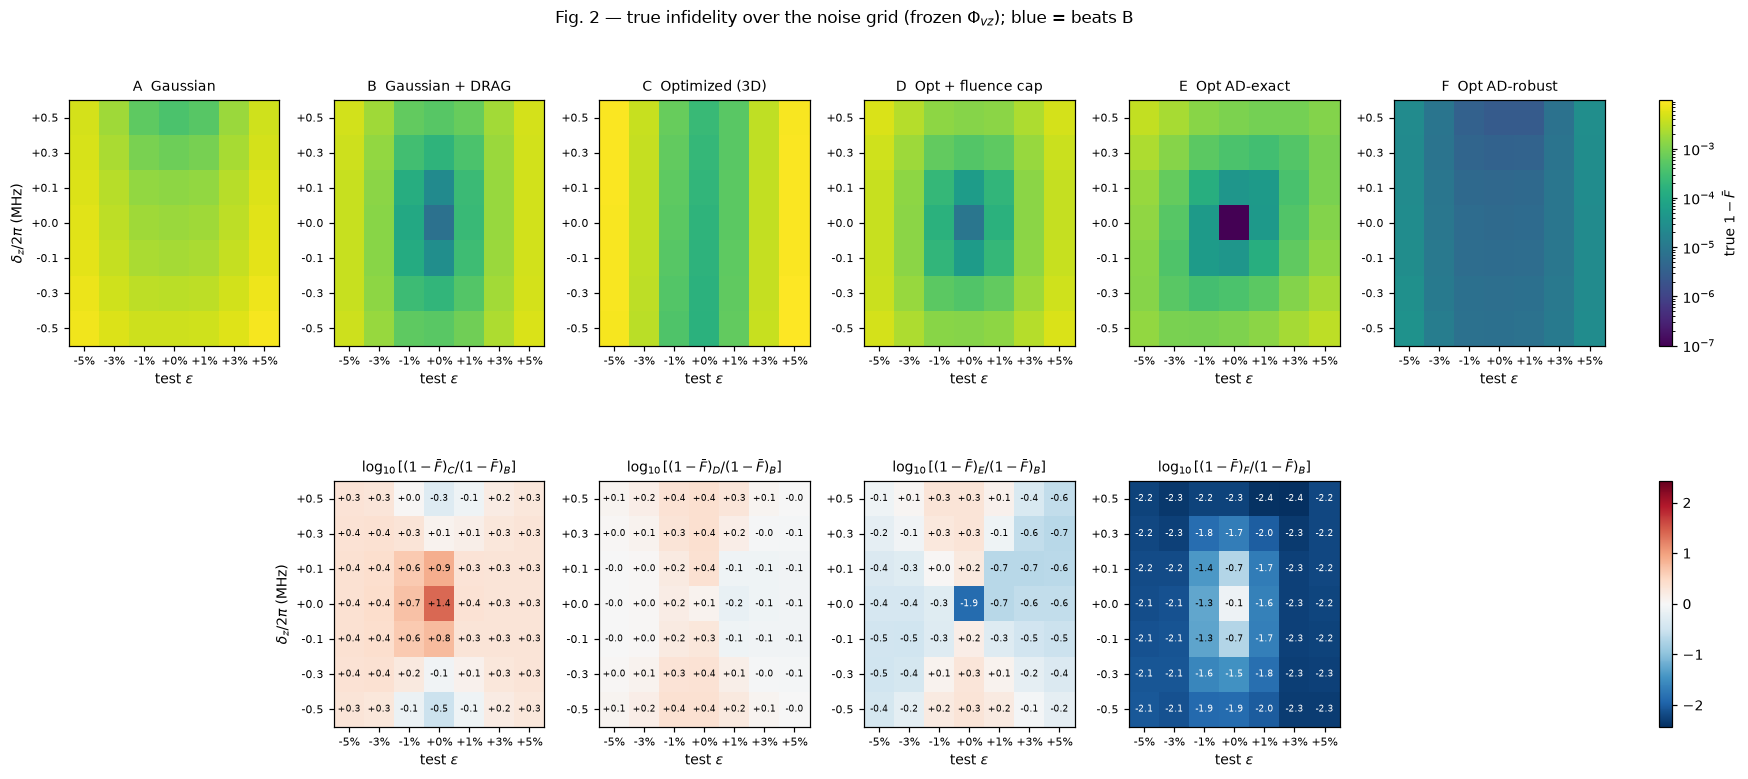

C beats B at 6 of 49 grid points.
D beats B at 18 of 49 grid points.
E beats B at 34 of 49 grid points.
F beats B at 49 of 49 grid points.


In [6]:
vmin = min(s.min() for s in sweeps.values())
vmax = max(s.max() for s in sweeps.values())
ext = [-0.5, len(al.EPS_GRID) - 0.5, -0.5, len(al.DELTA_MHZ_GRID) - 0.5]

def _noise_ticks(ax):
    ax.set_xticks(range(len(al.EPS_GRID)), [f"{e:+.0%}" for e in al.EPS_GRID], fontsize=7)
    ax.set_yticks(range(len(al.DELTA_MHZ_GRID)), [f"{d:+.1f}" for d in al.DELTA_MHZ_GRID], fontsize=7)
    ax.set_xlabel(r"test $\epsilon$")
    ax.grid(False)

n_arms = len(al.ARM_ORDER)
fig = plt.figure(figsize=(3.0 * n_arms + 0.8, 7.4))
gs = fig.add_gridspec(2, n_arms + 1, width_ratios=[1] * n_arms + [0.06], hspace=0.55, wspace=0.30)

for i, k in enumerate(al.ARM_ORDER):
    ax = fig.add_subplot(gs[0, i])
    im = ax.imshow(sweeps[k], origin="lower", aspect="auto", extent=ext,
                   norm=LogNorm(vmin=vmin, vmax=vmax), cmap="viridis")
    ax.set_title(f"{k}  {arms[k].name}", fontsize=9)
    _noise_ticks(ax)
    if i == 0:
        ax.set_ylabel(r"$\delta_z/2\pi$ (MHz)")
fig.colorbar(im, cax=fig.add_subplot(gs[0, n_arms]), label=r"true $1-\bar F$")

RATIO_ARMS = tuple(k for k in al.ARM_ORDER if k not in ("A", "B"))
ratios = {k: np.log10(sweeps[k] / sweeps["B"]) for k in RATIO_ARMS}
lim = max(np.max(np.abs(r)) for r in ratios.values())
for i, k in enumerate(RATIO_ARMS):
    ax = fig.add_subplot(gs[1, i + 1])
    im2 = ax.imshow(ratios[k], origin="lower", aspect="auto", extent=ext,
                    cmap="RdBu_r", vmin=-lim, vmax=lim)
    for r in range(ratios[k].shape[0]):
        for c in range(ratios[k].shape[1]):
            ax.text(c, r, f"{ratios[k][r, c]:+.1f}", ha="center", va="center", fontsize=6,
                    color="k" if abs(ratios[k][r, c]) < 0.6 * lim else "w")
    ax.set_title(rf"$\log_{{10}}[(1-\bar F)_{k} / (1-\bar F)_B]$", fontsize=9)
    _noise_ticks(ax)
    if i == 0:
        ax.set_ylabel(r"$\delta_z/2\pi$ (MHz)")
fig.colorbar(im2, cax=fig.add_subplot(gs[1, n_arms]))
fig.suptitle("Fig. 2 — true infidelity over the noise grid (frozen $\\Phi_{vz}$); blue = beats B", y=0.99)
plt.show()

for k in RATIO_ARMS:
    print(f"{k} beats B at {int((ratios[k] < 0).sum())} of {ratios[k].size} grid points.")


[WD]: I'm having a question here is why the dbcb only when the airabsluon is positive? It's a very stark nonsymmetry.  In principle，the sign not matters, only the magnitude.

[RE:] 好问题——「原则上只有 |ε| 该起作用」恰恰是**纯二阶（偶宇称）误差模型**的预言，而实测的强不对称正是它失效的指纹。机制：播出层的 Stark 相位补偿按标称 κ 编程，真实幅度是 (1+ε)κ 时补偿失配，产生一个**正比于 ε 一次方**（奇宇称）的有效挠率误差 δτ_eff ∝ εκ²/(Δ+τ)。它与各臂自身的固有相干残差**干涉**：总误差 ≈ |a + εb|² = |a|² + 2εRe(a*b) + ε²|b|²，中间的交叉项随 ε 变号。B 的固有残差相位使它在 ε>0 侧变差（不对称度 1.18），D 的残差相位恰好使交叉项接近零（不对称度 0.985）——所以 D/B 的蓝区集中在 ε>0 半平面，主要是 **B 在那一侧变差**，而不是 D 特别好。这个 δτ_eff 机制的定量对账（对五个波形算 κ²-加权闭合向量并与本图逐点核对）已立项为 F06d，尚未执行。

### Fig. 3 — the $\epsilon$ slice at $\delta_z = 0$

Solid = measured. Dashed = the budget's own prediction for that arm, i.e. $C_3$
rescaled to each $\epsilon$ (it is exactly quadratic in $\epsilon$).

Arms A and B have **the same** dashed curve: $C_3$ is a property of the design curve, and
DRAG only changes how that curve is played. That is the v5.1 correction — DRAG buys
leakage suppression, not amplitude robustness — visible directly.

Two things to read off: the **vertical gap** between an arm's dashed and solid curve is
how wrong the surrogate is for that arm; the **asymmetry** between $\pm\epsilon$ is a
direct read-out of the odd higher-order channel, which the even-in-$\epsilon$ budget
cannot represent at all.

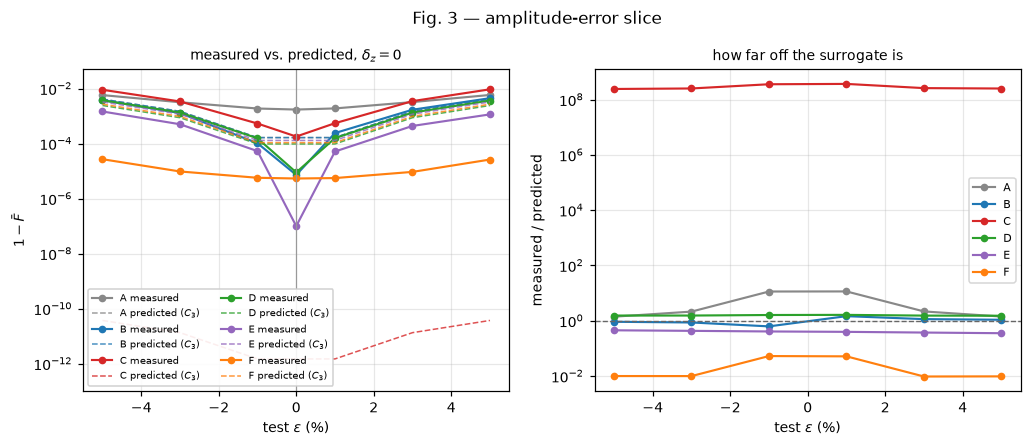

A: 1-F(+5%) = 5.8316e-03   1-F(-5%) = 5.7611e-03   asymmetry = 1.012
B: 1-F(+5%) = 4.4529e-03   1-F(-5%) = 3.7688e-03   asymmetry = 1.182
C: 1-F(+5%) = 9.3499e-03   1-F(-5%) = 9.0003e-03   asymmetry = 1.039
D: 1-F(+5%) = 3.6587e-03   1-F(-5%) = 3.7146e-03   asymmetry = 0.985
E: 1-F(+5%) = 1.1467e-03   1-F(-5%) = 1.4614e-03   asymmetry = 0.785
F: 1-F(+5%) = 2.6188e-05   1-F(-5%) = 2.6922e-05   asymmetry = 0.973


In [7]:
i0 = int(np.where(al.DELTA_MHZ_GRID == 0.0)[0][0])
fig, (ax, axr) = plt.subplots(1, 2, figsize=(11, 3.8))

nz = al.EPS_GRID != 0.0  # C3 is exactly 0 at eps = 0 and has no place on a log axis
for k in al.ARM_ORDER:
    ax.semilogy(al.EPS_GRID * 100, sweeps[k][i0], "o-", color=al.ARM_COLORS[k],
                lw=1.4, ms=4, label=f"{k} measured")
    pred = al.c3_prediction(arms[k])
    ax.semilogy(al.EPS_GRID[nz] * 100, pred[nz], "--", color=al.ARM_COLORS[k],
                lw=1.0, alpha=0.8, label=f"{k} predicted ($C_3$)")
ax.axvline(0, color="0.6", lw=0.8)
ax.set_xlabel(r"test $\epsilon$ (%)"); ax.set_ylabel(r"$1-\bar F$")
ax.set_title(r"measured vs. predicted, $\delta_z=0$", fontsize=9)
ax.set_ylim(1e-13, 5e-2)
ax.legend(fontsize=6.5, ncol=2, loc="lower left", framealpha=0.9)

for k in al.ARM_ORDER:
    s = sweeps[k][i0]
    pred = al.c3_prediction(arms[k])
    axr.semilogy(al.EPS_GRID[nz] * 100, s[nz] / pred[nz], "o-", color=al.ARM_COLORS[k],
                 lw=1.4, ms=4, label=k)
axr.axhline(1.0, color="0.4", ls="--", lw=0.9)
axr.set_xlabel(r"test $\epsilon$ (%)"); axr.set_ylabel("measured / predicted")
axr.set_title("how far off the surrogate is", fontsize=9)
axr.legend(fontsize=7)
fig.suptitle("Fig. 3 — amplitude-error slice", y=1.02)
plt.show()

for k in al.ARM_ORDER:
    s = sweeps[k][i0]
    j = int(np.where(al.EPS_GRID == 0.05)[0][0])
    jm = int(np.where(al.EPS_GRID == -0.05)[0][0])
    print(f"{k}: 1-F(+5%) = {s[j]:.4e}   1-F(-5%) = {s[jm]:.4e}   "
          f"asymmetry = {s[j]/s[jm]:.3f}")

## Fig. 4 — surrogate vs. truth along the optimization

Arm C's recorded run checkpointed every 100 iterations. The optimizer only ever saw the
surrogate; the true infidelity is recomputed here offline from each checkpoint's
coefficients (with $\Phi_{\rm vz}$ re-fitted at that iterate, as a real calibration
would be).

The bottom panel carries the diagnostics — fluence, peak utilisation, $\max|\tau|$ —
so that whatever correlates with the turnaround is visible next to it.

**Green: arm D's trajectory; purple: arm E's (AD-exact objective)** (the fluence-capped solve, checkpointed the
same way). The cap pins its fluence at 2$F_0$ (bottom panel), and its truth curve never
turns around — the surrogate stays an honest proxy all the way to the end.


checkpoint_trace(20260810_F06b_fluence_cap2_mi20000): dropped 3 checkpoint(s) violating the c1 entry ticket (iters [100, 200, 300])


checkpoint_trace(20260810_F06e_adexact_construction): dropped 2 checkpoint(s) violating the c1 entry ticket (iters [100, 200])


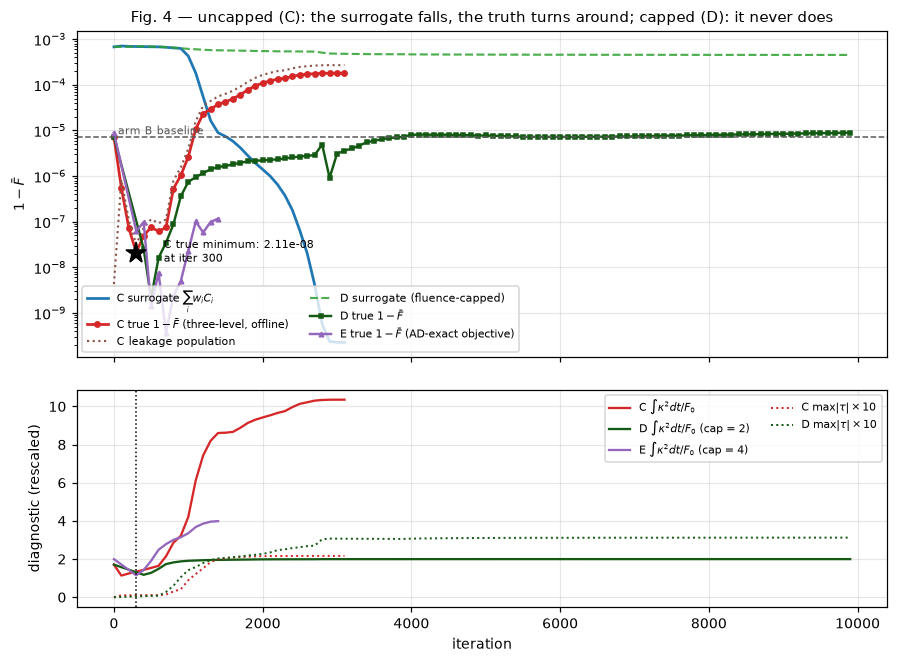

C start (warm start):  surrogate 6.775e-04   true 7.232e-06
C true minimum iter 300: true 2.112e-08   fluence/F0 1.34
C end:  surrogate 2.270e-10   true 1.795e-04   fluence/F0 10.36   (true rose 8502x from its minimum)
D end:  surrogate 4.515e-04   true 8.915e-06   fluence/F0 2.00   (true minimum along the way: 2.118e-09 at iter 500)
E end:  true 1.165e-07   fluence/F0 3.99   (E true minimum along the way: 3.736e-10 at iter 700)


In [8]:
tr = al.checkpoint_trace("C")
trd = al.checkpoint_trace("D")
tre = al.checkpoint_trace("E", trace=True)  # round 1: the D -> E descent arc

fig, (ax, axd) = plt.subplots(2, 1, figsize=(9.5, 6.8), sharex=True,
                              gridspec_kw={"height_ratios": [1.5, 1.0], "hspace": 0.12})

ax.semilogy(tr["iter"], tr["surrogate_total"], "-", lw=1.8, color="#1f77b4",
            label=r"C surrogate $\sum_i w_i C_i$")
ax.semilogy(tr["iter"], tr["true_infidelity"], "-o", lw=1.8, ms=3.5, color="#d62728",
            label=r"C true $1-\bar F$ (three-level, offline)")
ax.semilogy(tr["iter"], tr["leakage_population"], ":", lw=1.4, color="#8c564b",
            label="C leakage population")
ax.semilogy(trd["iter"], trd["surrogate_total"], "--", lw=1.4, color="#2ca02c", alpha=0.85,
            label="D surrogate (fluence-capped)")
ax.semilogy(trd["iter"], trd["true_infidelity"], "-s", lw=1.6, ms=2.6, color="#145a14",
            label=r"D true $1-\bar F$")
ax.semilogy(tre["iter"], tre["true_infidelity"], "-^", lw=1.6, ms=3.0, color="#9467bd",
            label=r"E true $1-\bar F$ (AD-exact objective)")
ax.axhline(rows["B"]["baseline_infidelity"], ls="--", lw=1.0, color="0.35")
ax.text(tr["iter"][0], rows["B"]["baseline_infidelity"], " arm B baseline",
        va="bottom", ha="left", fontsize=7, color="0.35")

kmin = int(np.argmin(tr["true_infidelity"]))
ax.plot(tr["iter"][kmin], tr["true_infidelity"][kmin], "*", ms=14, color="k", zorder=5)
ax.annotate(f"C true minimum: {tr['true_infidelity'][kmin]:.2e}\nat iter {int(tr['iter'][kmin])}",
            (tr["iter"][kmin], tr["true_infidelity"][kmin]),
            textcoords="offset points", xytext=(18, -6), fontsize=7.5)
ax.set_ylabel(r"$1-\bar F$")
ax.set_title("Fig. 4 — uncapped (C): the surrogate falls, the truth turns around; "
             "capped (D): it never does", fontsize=10)
ax.legend(fontsize=7, loc="lower left", ncol=2)

axd.plot(tr["iter"], tr["fluence_over_floor"], "-", lw=1.5, color="#d62728",
         label=r"C $\int\kappa^2dt / F_0$")
axd.plot(trd["iter"], trd["fluence_over_floor"], "-", lw=1.5, color="#145a14",
         label=r"D $\int\kappa^2dt / F_0$ (cap = 2)")
axd.plot(tre["iter"], tre["fluence_over_floor"], "-", lw=1.5, color="#9467bd",
         label=r"E $\int\kappa^2dt / F_0$ (cap = 4)")
axd.plot(tr["iter"], tr["max_abs_tau"] * 10, ":", lw=1.3, color="#d62728",
         label=r"C $\max|\tau|\times10$")
axd.plot(trd["iter"], trd["max_abs_tau"] * 10, ":", lw=1.3, color="#145a14",
         label=r"D $\max|\tau|\times10$")
axd.axvline(tr["iter"][kmin], color="k", ls=":", lw=1.0)
axd.set_xlabel("iteration"); axd.set_ylabel("diagnostic (rescaled)")
axd.legend(fontsize=7, ncol=2)
plt.show()

print(f"C start (warm start):  surrogate {tr['surrogate_total'][0]:.3e}   true {tr['true_infidelity'][0]:.3e}")
print(f"C true minimum iter {int(tr['iter'][kmin])}: true {tr['true_infidelity'][kmin]:.3e}   "
      f"fluence/F0 {tr['fluence_over_floor'][kmin]:.2f}")
print(f"C end:  surrogate {tr['surrogate_total'][-1]:.3e}   true {tr['true_infidelity'][-1]:.3e}   "
      f"fluence/F0 {tr['fluence_over_floor'][-1]:.2f}   (true rose "
      f"{tr['true_infidelity'][-1]/tr['true_infidelity'][kmin]:.0f}x from its minimum)")
kd = int(np.argmin(trd["true_infidelity"]))
print(f"D end:  surrogate {trd['surrogate_total'][-1]:.3e}   true {trd['true_infidelity'][-1]:.3e}   "
      f"fluence/F0 {trd['fluence_over_floor'][-1]:.2f}   (true minimum along the way: "
      f"{trd['true_infidelity'][kd]:.3e} at iter {int(trd['iter'][kd])})")
ke = int(np.argmin(tre["true_infidelity"]))
print(f"E end:  true {tre['true_infidelity'][-1]:.3e}   fluence/F0 {tre['fluence_over_floor'][-1]:.2f}"
      f"   (E true minimum along the way: {tre['true_infidelity'][ke]:.3e} at iter {int(tre['iter'][ke])})")


[WD]: is it true that for all the optimization we optimize more than 10000? from the above plots， it seems that we can stop early and performance is better?

## 4. Export

120-point CSVs (`time_ns, Omega_x_rad_per_ns, Omega_y_rad_per_ns`, the F07 schema),
coefficient JSONs for exact regeneration, and a manifest. The sampling loss is the
120-point infidelity over the fine-grid one — reported, not thresholded.

In [9]:
manifest = al.export_arms(arms, rows)
print(json.dumps(manifest["arms"], indent=1))
print("\nfiles:")
for p in sorted((Path.cwd() / "waveforms").iterdir()):
    print(f"  {p.relative_to(Path.cwd())}  ({p.stat().st_size} bytes)")

{
 "A": {
  "name": "Gaussian",
  "layer": "planar",
  "csv": "waveforms/A_gaussian_120pt.csv",
  "json": "waveforms/A_gaussian.json",
  "run_id": null,
  "infidelity_120pt": 0.0017185320709346419,
  "infidelity_fine": 0.0017185331283652294,
  "sampling_loss_ratio": 0.9999993846900185
 },
 "B": {
  "name": "Gaussian + DRAG",
  "layer": "planar_drag",
  "csv": "waveforms/B_gaussian_drag_120pt.csv",
  "json": "waveforms/B_gaussian_drag.json",
  "run_id": null,
  "infidelity_120pt": 7.229761351257302e-06,
  "infidelity_fine": 7.231667209062209e-06,
  "sampling_loss_ratio": 0.999736456649648
 },
 "C": {
  "name": "Optimized (3D)",
  "layer": "general",
  "csv": "waveforms/C_optimized_120pt.csv",
  "json": "waveforms/C_optimized.json",
  "run_id": "20260808_F06min_gaussian3d_construction",
  "infidelity_120pt": 0.0001764511485046194,
  "infidelity_fine": 0.00018086139869277762,
  "sampling_loss_ratio": 0.9756153042051292
 },
 "D": {
  "name": "Opt + fluence cap",
  "layer": "general",
  "cs

## 5. What the run says

Filled in from the numbers above, not in advance:

* Table 1 — which arm wins on the predicted budget, which wins on the truth, and the
  `true/pred` ratio per arm.
* Fig. 2/3 — whether the optimized arm's disadvantage shrinks or grows with $\epsilon$,
  and how asymmetric the $\pm\epsilon$ response is.
* Fig. 4 — where along the trajectory the true infidelity turns around, and which
  diagnostic moves with it.

That last one is the input to the next conversation: what to constrain, or what to add
to the model, so that minimizing the surrogate stays inside the region where the
surrogate means something.